In [47]:
import fitness_landscape as fl
from fitness_landscape.utils import fasta_to_prot20_sequences
from fitness_landscape.core.landscape import FitnessLandscape
from fitness_landscape.transforms.eigenmode import eigenmode_decomposition
from collections import defaultdict
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import re
import pickle
import json
from tqdm import tqdm
import networkx as nx
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import spearmanr
from scipy.stats import norm
import matplotlib as mpl
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.patches import Circle
import matplotlib as mpl
from scipy.stats import mannwhitneyu
import seaborn as sns
import scipy.stats as stats

### NK min composition simulations

In [2]:
def _pad_var_by_order(var_by_order: dict, max_order: int) -> np.ndarray:
    """Return variance explained array v[0..max_order]. Missing orders -> 0."""
    v = np.zeros(max_order + 1, dtype=float)
    for k, val in var_by_order.items():
        try:
            kk = int(k)
        except Exception:
            continue
        if 0 <= kk <= max_order:
            v[kk] = float(val)
    return v

def run_min_comp_experiment(
    fl,
    N: int,
    K: int,
    m: int,
    seed: int,
    max_order: int = None,
    alpha_align: float = 0.0,
):
    """
    Creates m NK landscapes (N,K), optionally correlated via alpha_align, min-composes them,
    attaches the composite to a base landscape, and returns metrics + variance-by-order vector.

    alpha_align:
      0.0 -> independent constraints
      1.0 -> identical constraints (all equal to shared)
    """
    assert 0 <= K < N
    if max_order is None:
        # For binary sequences, Walsh orders go 0..N
        max_order = N

    rng = np.random.default_rng(seed)

    # Shared component (for alignment control)
    shared = fl.models.nk.create_nk_binary_landscape(N=N, K=K, seed=int(rng.integers(1e9)))
    shared_signal = shared.fitness_layers[f"nk_k={K}"].to_scalar()

    signals = []
    for _ in range(m):
        ind = fl.models.nk.create_nk_binary_landscape(N=N, K=K, seed=int(rng.integers(1e9)))
        ind_signal = ind.fitness_layers[f"nk_k={K}"].to_scalar()

        if alpha_align > 0:
            sig = alpha_align * shared_signal + (1 - alpha_align) * ind_signal
        else:
            sig = ind_signal

        signals.append(sig)

    stacked = np.stack(signals, axis=0)  # shape (m, 2^N)
    min_comp = np.min(stacked, axis=0)
    # Collect indices of min position to find boundaries
    min_idx = np.argmin(stacked, axis=0)

    # Alignment diagnostic: mean pairwise Pearson corr across constituent signals
    # (Compute on raw vectors; if constant, corr can be nan -> handle.)
    corr = np.corrcoef(stacked)
    # upper triangle mean excluding diagonal
    if m > 1:
        ut = corr[np.triu_indices(m, k=1)]
        mean_pairwise_corr = np.nanmean(ut)
    else:
        mean_pairwise_corr = np.nan

    # Attach composite to a base landscape (K=0 is fine; you just need the genotype graph)
    base = fl.models.nk.create_nk_binary_landscape(N=N, K=0, seed=int(rng.integers(1e9)))

    # Attach categorical boundary
    layer_name = "min_boundary"
    base.attach(name=layer_name, values=min_idx, dtype="categorical")

    # Attached numeric composite
    layer_name = "composite_min"
    base.attach(name=layer_name, values=min_comp, dtype="numeric")
    base.view(layer_name)

    
    res = fl.analysis.epistasis.calculate_epistasis_walsh(base, order=max_order)
    var_by_order = res.get("variance_explained", {})
    v = _pad_var_by_order(var_by_order, max_order=max_order)

    high_order_frac = float(v[2:].sum()) if len(v) > 2 else 0.0
    # Ignore order 0 in centroid (optional). Here I use orders 1..max_order.
    denom = float(v[1:].sum()) if v[1:].sum() > 0 else 1.0
    centroid = float((np.arange(1, max_order + 1) * v[1:]).sum() / denom)

    # "effective max order" = highest order above tiny epsilon
    eps = 1e-6
    nz = np.where(v > eps)[0]
    eff_max_order = int(nz.max()) if nz.size else 0
    tmap_res = fl.analysis.diffusion_scale.compute_ruggedness_diffusion_scale(base, t_min=1e-10, t_max=1e2)
    tmap = float(tmap_res.get("t_map", np.nan))
    tmap_upper_ci = float(tmap_res.get("t_upper_confidence_interval", np.nan))
    tmap_lower_ci = float(tmap_res.get("t_lower_confidence_interval", np.nan))

    out = {
        "N": N,
        "K": K,
        "m": m,
        "seed": seed,
        "alpha_align": alpha_align,
        "mean_pairwise_corr": mean_pairwise_corr,
        "high_order_frac_ge2": high_order_frac,
        "epistasis_centroid": centroid,
        "eff_max_order": eff_max_order,
        "tmap": tmap,
        "tmap_upper_ci": tmap_upper_ci,
        "tmap_lower_ci": tmap_lower_ci,
        # Store NK landscape in dict
        "nk_landscape": base,
    }

    # store variance-by-order as separate columns for easy plotting/aggregation
    for o in range(max_order + 1):
        out[f"v{o}"] = float(v[o])

    return out

def sweep_all(
    fl,
    Ns=(5,6,7,8),
    Ks=(0,1,2,3),
    ms=(1,2,4,8,16),
    alphas=(0.0, 0.25, 0.5, 0.75, 1.0),
    seeds=range(25),
):
    rows = []
    for _,N in tqdm(enumerate(Ns)):
        for K in Ks:
            if K >= N:
                continue
            for m in ms:
                for a in alphas:
                    for seed in seeds:
                        rows.append(run_min_comp_experiment(
                            fl=fl,
                            N=N, K=K, m=m,
                            seed=seed,
                            max_order=N,          # Walsh orders 0..N
                            alpha_align=a,
                        ))
    return rows

In [3]:
nk_results = sweep_all(fl, Ns=[4,5,6], Ks=[0], ms=[2,4,8,10,20,50,100], alphas=[0.0,0.25,0.5,0.75, 0.9,1.0], seeds=range(10))
df = pd.DataFrame(nk_results)

0it [00:00, ?it/s]

3it [09:39, 193.26s/it]


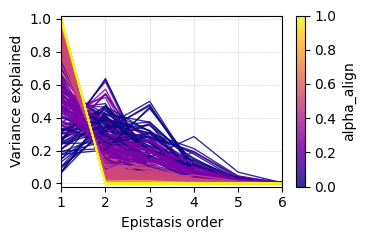

In [6]:
color_by = "alpha_align"

# find variance columns v0, v1, ...
vcols = sorted(
    [c for c in df.columns if c.startswith("v") and c[1:].isdigit()],
    key=lambda x: int(x[1:])
)

# drop v0 if you don't want order-0 (your code was doing this)
vcols = [c for c in vcols if int(c[1:]) != 0]

if len(vcols) == 0:
    raise ValueError("No variance columns found (expected v0, v1, ...).")

orders = np.array([int(c[1:]) for c in vcols], dtype=float)

Y_all = df[vcols].to_numpy(dtype=float)
C_all = df[color_by].to_numpy(dtype=float)

good = np.isfinite(Y_all).all(axis=1) & np.isfinite(C_all)
Y = Y_all[good]
C = C_all[good]

lines = [np.column_stack([orders, y]) for y in Y]

norm = Normalize(vmin=np.nanmin(C), vmax=np.nanmax(C))

lc = LineCollection(lines, cmap=plt.cm.plasma, norm=norm, linewidths=1, alpha=0.85)
lc.set_array(C)

# Plot (create fig explicitly)
fig, ax = plt.subplots(figsize=(3.75, 2.5))
ax.add_collection(lc)

ax.set_xlim(orders.min(), orders.max())
ymin = np.nanmin(Y)
ymax = np.nanmax(Y)
pad = 0.02 * (ymax - ymin) if ymax > ymin else 0.05
ax.set_ylim(ymin - pad, ymax + pad)

ax.set_xlabel("Epistasis order")
ax.set_ylabel("Variance explained")

cbar = fig.colorbar(lc, ax=ax)
cbar.set_label(color_by)

ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)
fig.tight_layout()
fig.savefig("../figures/figure_3/var_by_order_min_compose.pdf")
plt.show()

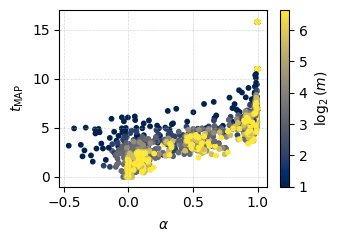

In [7]:
plt.figure(figsize=(3.5, 2.5))

df['log2_m'] = np.log2(df['m'])

sc = plt.scatter(
    df['mean_pairwise_corr'],
    df['tmap'],
    c=df['log2_m'],
    cmap='cividis',
    s=10
)

plt.ylabel(r"$t_{\mathrm{MAP}}$")
plt.xlabel(r"$\alpha_{\mathrm{}}$")

cbar = plt.colorbar(sc)
cbar.set_label(r"$\log_2(m)$")

plt.ylim(-1, 17)
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.savefig('../figures/figure_3/alpha_vs_tmap.pdf')
plt.show()



/tmp/ipykernel_51013/4010837356.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


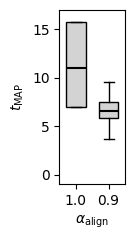

In [8]:
df_sub = df[df["alpha_align"].isin([1.0, 0.9])]

# Collect data in order
data = [
    df_sub[df_sub["alpha_align"] == 1.0]["tmap"].values,
    df_sub[df_sub["alpha_align"] == 0.9]["tmap"].values,
]

plt.figure(figsize=(1.45, 2.5))

plt.boxplot(
    data,
    labels=["1.0", "0.9"],
    showfliers=False,
    widths=0.6,
    patch_artist=True,
    boxprops=dict(facecolor="lightgray", alpha=1),
    medianprops=dict(color="black", linewidth=1.5),
    whiskerprops=dict(color="black", alpha=1),
    capprops=dict(color="black", alpha=1),
)

plt.xlabel(r"$\alpha_{\mathrm{align}}$")
plt.ylabel(r"$t_{\mathrm{MAP}}$")
# plt.xticks(rotation=90)
plt.ylim(-1, 17)
plt.tight_layout()

plt.savefig("../figures/figure_3/tmap_vs_alpha_align_boxplot.pdf")
plt.show()

In [9]:
# Test for significance

x = df[df["alpha_align"] == 1.0]["tmap"].values
y = df[df["alpha_align"] == 0.9]["tmap"].values

u_stat, p_value = mannwhitneyu(x, y, alternative="two-sided")

print("Mann–Whitney U:", u_stat)
print("p-value:", p_value)

Mann–Whitney U: 38360.0
p-value: 2.775776465742926e-39


### Diagrammatic demonstration of solution sets and intersections between selective pressures

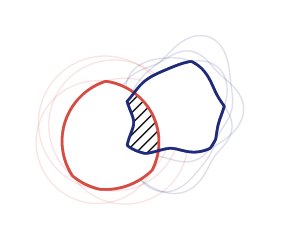

In [ ]:

def blob_params(seed, a1=0.18, a2=0.10, a3=0.06):
    rng = np.random.default_rng(seed)
    p1, p2, p3 = rng.uniform(0, 2*np.pi, size=3)
    return (a1, a2, a3, p1, p2, p3)

def inside_blob(X, Y, center, R, params):
    cx, cy = center
    dx = X - cx
    dy = Y - cy
    t = np.arctan2(dy, dx)
    r = np.sqrt(dx*dx + dy*dy)

    a1, a2, a3, p1, p2, p3 = params
    r_theta = R * (1
                   + a1*np.cos(2*t + p1)
                   + a2*np.sin(3*t + p2)
                   + a3*np.cos(5*t + p3))
    return r <= r_theta

def inside_circle(X, Y, center, R):
    cx, cy = center
    return (X - cx)**2 + (Y - cy)**2 <= R**2

def jitter_offsets(n, scale=0.10, seed=0):
    rng = np.random.default_rng(seed)
    offs = rng.normal(0, scale, size=(n, 2))
    offs[:, 0] *= 1.2
    offs[:, 1] *= 0.8
    return offs

def blob_outer_radius(R, params):
    # conservative bound on max radius of the blob
    a1, a2, a3, *_ = params
    return R * (1 + abs(a1) + abs(a2) + abs(a3))

#  styling
RED  = "#d84b43"
BLUE = "#1f2a7a"
FILL = "#B2B2B2"

xlim = (-1.10, 1.35)
ylim = (-1.00, 1.00)

# Red set C_2^1: intersection of several slightly shifted circles
red_center = (-0.10, -0.10)
red_R = 0.72
K_red = 4
red_offsets = jitter_offsets(K_red, scale=0.11, seed=12)

red_micro = []
for i, (dx, dy) in enumerate(red_offsets):
    Ri = red_R * (0.96 + 0.04*np.cos(i))
    ci = (red_center[0] + dx, red_center[1] + dy)
    red_micro.append((ci, Ri))

# Blue set C_1^2: intersection of several slightly shifted blobs
blue_center = (0.60, 0.15)
blue_R = 0.64
K_blue = 4
blue_offsets = jitter_offsets(K_blue, scale=0.10, seed=23)

blue_micro = []
for i, (dx, dy) in enumerate(blue_offsets):
    ci = (blue_center[0] + dx, blue_center[1] + dy)
    Ri = blue_R * (0.95 + 0.04*np.sin(i))
    params = blob_params(seed=4 + 11*i, a1=0.16, a2=0.09, a3=0.05)
    blue_micro.append((ci, Ri, params))

pad_frac = 0.12  # increase if you want more whitespace around everything

# tight bounds from red circles
xmin = min(c[0] - R for (c, R) in red_micro)
xmax = max(c[0] + R for (c, R) in red_micro)
ymin = min(c[1] - R for (c, R) in red_micro)
ymax = max(c[1] + R for (c, R) in red_micro)

# add bounds from blue blobs (conservative)
for (c, R, params) in blue_micro:
    Rout = blob_outer_radius(R, params)
    xmin = min(xmin, c[0] - Rout)
    xmax = max(xmax, c[0] + Rout)
    ymin = min(ymin, c[1] - Rout)
    ymax = max(ymax, c[1] + Rout)

dx = xmax - xmin
dy = ymax - ymin
xlim2 = (xmin - pad_frac*dx, xmax + pad_frac*dx)
ylim2 = (ymin - pad_frac*dy, ymax + pad_frac*dy)

nx, ny = 900, 720
xs = np.linspace(*xlim2, nx)
ys = np.linspace(*ylim2, ny)
X, Y = np.meshgrid(xs, ys)

red_masks  = [inside_circle(X, Y, c, R) for (c, R) in red_micro]
C_red      = np.logical_and.reduce(red_masks)

blue_masks = [inside_blob(X, Y, c, R, params) for (c, R, params) in blue_micro]
C_blue     = np.logical_and.reduce(blue_masks)

C_obs      = C_red & C_blue

mpl.rcParams["hatch.color"] = "black"
mpl.rcParams["hatch.linewidth"] = 1.0
mpl.rcParams["pdf.fonttype"] = 42   # Illustrator-friendly
mpl.rcParams["ps.fonttype"] = 42

fig, ax = plt.subplots(figsize=(3, 3))

plt.rcParams["hatch.linewidth"] = 1.0  # thickness of hatch strokes

for (c, R) in red_micro:
    ax.add_patch(Circle(c, R, fill=False, lw=1, ec=RED, alpha=0.15))

for m in blue_masks:
    ax.contour(X, Y, m.astype(float), levels=[0.5], colors=[BLUE],
               linewidths=1, alpha=0.15)

ax.contourf(
    X, Y, C_red.astype(float),
    levels=[0.5, 1.5],
    colors=["white"],
    alpha=1.0,
    zorder=5,
)

ax.contourf(
    X, Y, C_blue.astype(float),
    levels=[0.5, 1.5],
    colors=["white"],
    alpha=1.0,
    zorder=6,
)

ax.contourf(
    X, Y, C_obs.astype(float),
    levels=[0.5, 1.5],
    colors="none",      # no facecolor
    hatches=["///"],    # hatch only
    zorder=7,
)

ax.contour(X, Y, C_red.astype(float),  levels=[0.5], colors=[RED],  linewidths=2.0, zorder=10)
ax.contour(X, Y, C_blue.astype(float), levels=[0.5], colors=[BLUE], linewidths=2.0, zorder=10)

# limits/aspect
ax.set_xlim(*xlim2)
ax.set_ylim(*ylim2)
ax.set_aspect("equal", adjustable="box")
ax.set_axis_off()

plt.tight_layout()
plt.savefig('../figures/figure_3/intersection_solution_space.pdf', bbox_inches="tight", pad_inches=0)
plt.show()

### Boundary switching

In [6]:
# Edgewise energy

def boundary_edge_dirichlet_energy(landscape, *,
                                   boundary_layer="min_boundary",
                                   signal_layer="composite_min",
                                   weighted=False,
                                   aggregate_func=np.mean):
    G = landscape.graph

    boundary = {n: G.nodes[n][f"fitness_{boundary_layer}"] for n in G.nodes()}

    def _to_scalar(x):
        if isinstance(x, (list, tuple, np.ndarray)):
            return float(aggregate_func(x))
        return float(x)

    signal = {n: _to_scalar(G.nodes[n][f"fitness_{signal_layer}"]) for n in G.nodes()}
    
    boundary_total = 0.0
    internal_total = 0.0
    boundary_count = 0
    internal_count = 0
    total = 0.0

    for u, v, data in G.edges(data=True):

        w = data.get("weight", 1.0)
        de = 0.5 * (signal[u] - signal[v])**2
        if weighted:
            de *= w
        # Total edge-wise Dirichlet energy
        total += de 
        
        # Cross boundary
        if boundary[u] != boundary[v]:    
            boundary_total += de
            boundary_count += 1
        
        else:
            internal_total += de
            internal_count += 1

    return boundary_total / boundary_count if boundary_count > 0 else 0, internal_total / internal_count if internal_count > 0 else 0, total


def get_high_pass_signal_by_index(landscape, signal_layer="composite_min", N=None, A=2):
    """
    Filters out additive components by zeroing out the first N*(A-1) 
    eigenvectors (the 'additive band').
    """
    # Perform Graph Fourier Transform
    eigvecs, eigvals, coeffs = fl.transforms.graph_fourier_transform(landscape)
    
    #  Calculate the exact additive cutoff
    # N = sequence length, A = alphabet size (e.g., 2 for binary)
    if N is None:
        # Fallback: estimate N if not provided, assuming binary Hamming graph
        N = int(np.log2(len(eigvals))) 
    
    # Index 0 is the constant (mean) mode. Indices 1 to M are additive.
    # We want to keep everything AFTER index M.
    additive_cutoff = N * (A - 1)
    
    # Create the filter kernel
    # Add 1 to include the index 0 (DC component) in the mask
    filter_kernel = np.zeros_like(eigvals)
    filter_kernel[additive_cutoff + 1:] = 1.0
    
    # 4. Reconstruct filtered signal
    f_high = eigvecs @ (coeffs * filter_kernel)
    return f_high


def get_switching_edges(landscape, boundary_layer="min_boundary"):
    """
    Returns a list of edge tuples where the identity of the 
    limiting constraint changes.
    """
    G = landscape.graph
    switching_edges = []
    
    # Map node to its limiting constraint ID
    boundary_map = {n: G.nodes[n][f"fitness_{boundary_layer}"] for n in G.nodes()}
    
    for u, v in G.edges():
        if boundary_map[u] != boundary_map[v]:
            switching_edges.append((u, v))
            
    return switching_edges


In [7]:
def plot_ruggedness_localization(landscape, switching_edges, signal_layer="high_pass_signal"):
    G = landscape.graph
    pos = nx.spring_layout(G, seed=42) # Or your custom x,y coords
    
    # 1. Get the signal for node coloring
    node_values = [G.nodes[n][f'fitness_{signal_layer}'] for n in G.nodes()]
    
    plt.figure(figsize=(8, 8))
    
    # 2. Draw all edges (low alpha)
    nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='gray')
    
    # 3. Draw Switching Edges (bold and colored)
    nx.draw_networkx_edges(G, pos, edgelist=switching_edges, 
                           width=2.5, edge_color='red', label="Switching Boundary")
    
    # 4. Draw Nodes colored by High-Pass energy
    nodes = nx.draw_networkx_nodes(G, pos, node_size=100, 
                                   node_color=node_values, cmap='viridis')
    
    plt.colorbar(nodes, label=f"{signal_layer} intensity")
    plt.title("Localization of High-Frequency Ruggedness at Switching Boundaries")
    plt.legend()
    plt.show()

    

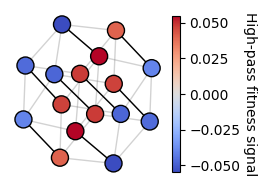

In [55]:
idx = 7

nk = nk_results[idx]['nk_landscape']
if "high_pass_signal" in nk.fitness_layers:
    nk.detach("high_pass_signal")
nk.view("composite_min")
layer_name = "high_pass_signal"
f_high = get_high_pass_signal_by_index(nk, signal_layer="composite_min", N=nk_results[idx]['N'])
nk.attach(name=layer_name, values=f_high, dtype="numeric")
nk.view('high_pass_signal')

s_edges = get_switching_edges(nk)


G = nk.graph
pos = nx.spring_layout(G, seed=2)
node_values = [G.nodes[n][f'fitness_high_pass_signal'] for n in G.nodes()]

plt.figure(figsize=(2.75, 2))

nx.draw_networkx_edges(G, pos, alpha=0.35, edge_color='gray')
nx.draw_networkx_edges(G, pos, edgelist=s_edges, width=1, edge_color='black')

nodes = nx.draw_networkx_nodes(
    G, pos,
    node_size=150,
    node_color=node_values,
    cmap='coolwarm',
    edgecolors='black',
    linewidths=1
)

cbar = plt.colorbar(nodes, fraction=0.046, pad=0.04)
cbar.set_label("High-pass fitness signal", rotation=270, labelpad=12)

plt.axis("off")
plt.tight_layout()
plt.savefig('../figures/figure_3/ruggedness_localization_example.pdf')
plt.show()

/tmp/ipykernel_57914/4151912840.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


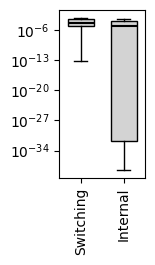

In [60]:

def get_high_pass_signal(landscape, N, A=2):
    """
    Filters out the additive components (lowest N*(A-1) modes) to isolate 
    the ruggedness residuals created by switching boundaries.
    """
    # Assuming fl is your fitness landscape library
    eigvecs, eigvals, coeffs = fl.transforms.graph_fourier_transform(landscape)
    
    # Calculate index-based cutoff for additive components
    # Index 0 is constant, 1 to N*(A-1) are additive
    additive_cutoff = N * (A - 1)
    
    filter_kernel = np.zeros_like(eigvals)
    filter_kernel[additive_cutoff + 1:] = 1.0
    
    # Reconstruct the signal
    f_high = eigvecs @ (coeffs * filter_kernel)
    return f_high

def collect_edge_energies(landscape, f_high, boundary_layer="min_boundary"):
    """
    Computes individual Dirichlet energies for every edge and labels them 
    as 'Switching' or 'Internal'.
    """
    G = landscape.graph
    boundary = {n: G.nodes[n][f"fitness_{boundary_layer}"] for n in G.nodes()}
    
    # Create a mapping of signal values for quick lookup
    # Mapping f_high array back to node order in the graph
    node_to_val = {node: val for node, val in zip(G.nodes(), f_high)}
    
    switching_energies = []
    internal_energies = []

    for u, v in G.edges():
        # Edge Dirichlet Energy: 0.5 * (f_u - f_v)^2
        de = 0.5 * (node_to_val[u] - node_to_val[v])**2
        
        if boundary[u] != boundary[v]:
            switching_energies.append(de)
        else:
            internal_energies.append(de)
            
    return switching_energies, internal_energies

# Main loop

all_switching = []
all_internal = []

for idx, row in df.iterrows():
    nk = row['nk_landscape']
    N = row['N']
    
    f_high = get_high_pass_signal(nk, N=N, A=2)

    s_eng, i_eng = collect_edge_energies(nk, f_high)
    
    all_switching.extend(s_eng)
    all_internal.extend(i_eng)


data = [np.array(all_switching), np.array(all_internal)]
labels = ["Switching", "Internal"]

plt.figure(figsize=(1.65, 2.75))

bp = plt.boxplot(
    data,
    labels=labels,
    showfliers=False,
    widths=0.6,
    patch_artist=True,
    boxprops=dict(facecolor="lightgray", alpha=1),
    medianprops=dict(color="black", linewidth=1.5),
    whiskerprops=dict(color="black", alpha=1),
    capprops=dict(color="black", alpha=1),
)

plt.yscale("log")
# plt.ylabel(r"Edgewise Dirichlet Energy (High-Pass)")
# plt.xlabel("Edge type")

# Optional: tidy x labels for narrow panel
plt.xticks(rotation=90)

# # Put stats text in a consistent spot (axes coords; works well with log scale)
# plt.text(
#     0.5, 0.95,
#     rf"$p = {p_value:.1e}$" + "\n" + rf"$\mu_S/\mu_I = {mean_ratio:.2f}$",
#     transform=plt.gca().transAxes,
#     ha="center", va="top",
#     fontsize=8,
# )

plt.tight_layout()
plt.savefig("../figures/figure_3/edge_energy_switching_vs_internal_boxplot.pdf")
plt.show()

In [11]:
nk = nk_results[0]['nk_landscape']
boundary_edge_dirichlet_energy(nk)

(0.0012296265376897473, 0.002675549009542121, 0.07405018853052889)

/home/matthewspence/graph-ruggedness-de/.env/lib/python3.13/site-packages/fitness_landscape/core/landscape.py:1649: RuntimeWarning: Plotly unavailable (plotly is required for interactive plotting.); falling back to matplotlib rendering.
  warnings.warn(


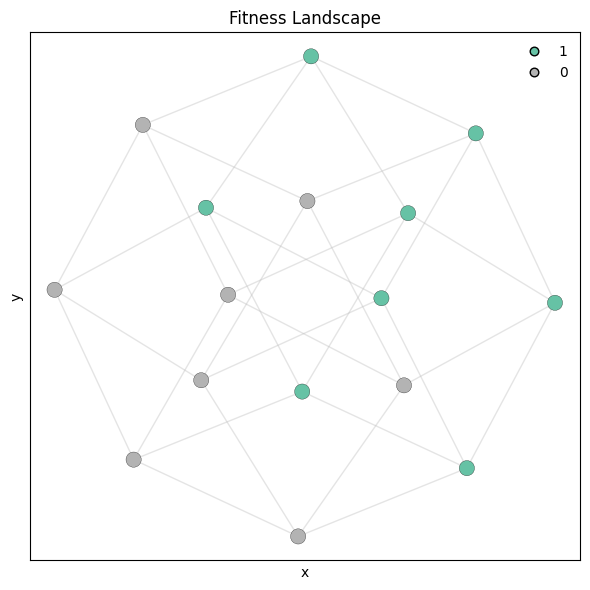

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Fitness Landscape'}, xlabel='x', ylabel='y'>)

In [12]:
nk = nk_results[0]['nk_landscape']
nk.view('min_boundary')
nk.plot()

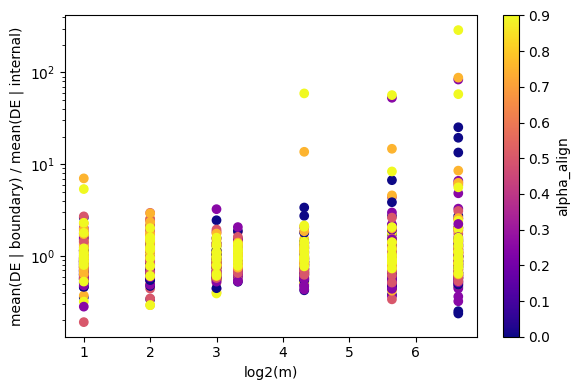

In [69]:
def boundary_energy_enrichment(
    landscape,
    boundary_layer="min_boundary",
    signal_layer="composite_min",
    weighted=False,
    aggregate_func=np.mean,
    eps=1e-12,
):
    G = landscape.graph

    boundary = {n: G.nodes[n][f"fitness_{boundary_layer}"] for n in G.nodes()}

    def _to_scalar(x):
        if isinstance(x, (list, tuple, np.ndarray)):
            return float(aggregate_func(x))
        return float(x)

    signal = {n: _to_scalar(G.nodes[n][f"fitness_{signal_layer}"]) for n in G.nodes()}

    de_boundary = []
    de_internal = []

    for u, v, data in G.edges(data=True):
        w = data.get("weight", 1.0)
        de = 0.5 * (signal[u] - signal[v])**2
        if weighted:
            de *= w

        if boundary[u] != boundary[v]:
            de_boundary.append(de)
        else:
            de_internal.append(de)

    de_boundary = np.asarray(de_boundary, float)
    de_internal = np.asarray(de_internal, float)

    muB = de_boundary.mean() if len(de_boundary) else np.nan
    muI = de_internal.mean() if len(de_internal) else np.nan

    ratio = (muB + eps) / (muI + eps)   # >1 means boundary edges hotter on average
    diff  = muB - muI                   # absolute increase

    fracB = len(de_boundary) / (len(de_boundary) + len(de_internal) + eps)

    return dict(muB=muB, muI=muI, ratio=ratio, diff=diff,
                nB=len(de_boundary), nI=len(de_internal), fracB=fracB)

rows = []
for nk in df["nk_landscape"]:
    rows.append(boundary_energy_enrichment(nk))

metrics = pd.DataFrame(rows)
df_test = pd.concat([df.reset_index(drop=True), metrics], axis=1)

plt.figure(figsize=(6,4))
plt.scatter(
    df_test["log2_m"],
    df_test["ratio"],
    c=df_test["alpha_align"],
    cmap="plasma",
)
plt.yscale("log")
plt.xlabel("log2(m)")
plt.ylabel("mean(DE | boundary) / mean(DE | internal)")
plt.colorbar(label="alpha_align")
plt.tight_layout()
plt.show()